# Passive compliance — weight loading

How the hand's **torsional (joint-space) spring stiffness** determines the
steady-state index-finger deflection under incrementally added weights.
The finger is commanded to hold `WEIGHT_INDEX`; each weight step deflects it
further toward extension.  Higher stiffness → smaller angular deviation for
the same load.

Deviation is computed as the mean across the MCP and PIP joints
(DIP is a mimic joint, mechanically coupled to PIP).

In [20]:
import sys as _sys, os as _os
_sys.path.insert(0, _os.path.join('../..'))
from plot_config import COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size  # style auto-applied

FIG_W = FIG_W_DOUBLE * 0.9  # 7.09 in — standard Nature Comms double column

FIG_H = FIG_W * (4 / 12)

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)


In [21]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('../../'))
import plot_config   # auto-applies shared mplstyle
from hand_config import (
    STIFFNESS_CONDITIONS,
    WEIGHT_LABELS, WEIGHT_LOG_DURATION,
    WEIGHT_INDEX,
)

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
OUTPUT = os.path.join('outputs', 'weight_compliance_hand')
os.makedirs(OUTPUT, exist_ok=True)

# Index finger motors: 5 = MCP, 6 = PIP  (DIP is mimic of PIP, not logged)
IDX_MOTORS = [5, 6]
N_STEPS    = 1 + len(WEIGHT_LABELS)   # 0 = no weight, 1..N = weight steps

def _synth(k):
    rng = np.random.default_rng(int(k * 1000))
    rows = []
    t = 0.0; dt = 0.02
    n = int(WEIGHT_LOG_DURATION / dt)
    for step in range(N_STEPS):
        delta = (step / (N_STEPS - 1)) * (0.3 / k)
        for _ in range(n):
            q5 = max(0.0, WEIGHT_INDEX[0] - delta       + rng.normal(0, 0.004))
            q6 = max(0.0, WEIGHT_INDEX[1] - delta * 0.6 + rng.normal(0, 0.004))
            row = {'time_s': f'{t:.3f}', 'k_rot': k, 'weight_step': step,
                   'q_5': f'{q5:.5f}', 'q_6': f'{q6:.5f}',
                   'qdot_5': '0', 'qdot_6': '0', 'tau_5': '0', 'tau_6': '0'}
            rows.append(row); t += dt
    return pd.DataFrame(rows)

DEMO = False
def load(k):
    global DEMO
    path = os.path.join(OUTPUT, f'data_K{k:.3f}.csv')
    if os.path.isfile(path):
        return pd.read_csv(path)
    DEMO = True
    return _synth(k)

DATA = {k: load(k) for k in STIFFNESS_CONDITIONS}
banner = ' DEMO (synthetic) data ' if DEMO else ' measured data '
print(f'Loaded{banner}|  K levels: {STIFFNESS_CONDITIONS}')


Loaded measured data |  K levels: [0.05, 0.3]


## Cumulative joint deviation vs weight step

Each curve is one stiffness condition.  Value = $|\Delta\theta_\mathrm{MCP}| + |\Delta\theta_\mathrm{PIP}|$, where deviation is measured from the no-weight baseline.

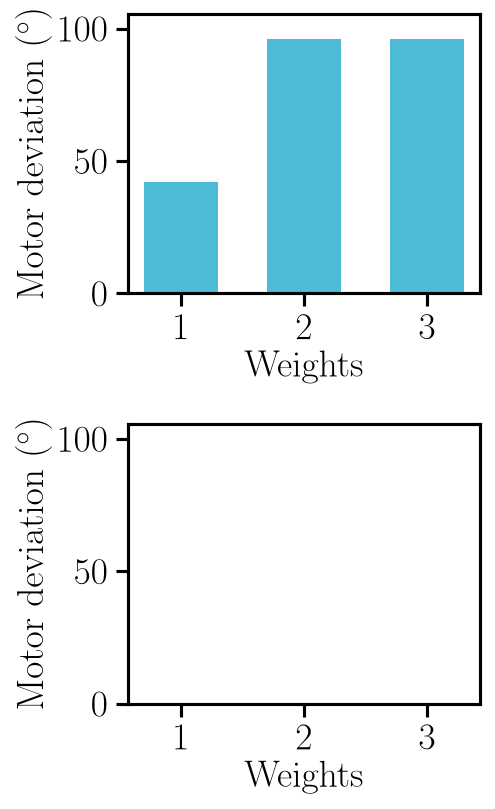

In [22]:
# Two stacked panels (soft / stiff controller); three bars each = deviation at
# the successive added weights (1, 2, 3). Shared linear y-axis exposes the gap.
BAR_W = 5.2*0.7  # figure width (in)
BAR_H = 8.2*0.7   # figure height (in)

steps        = list(range(N_STEPS))   # 0 = no weight, 1..3 = weight steps
weight_steps = steps[1:]              # drop the no-weight baseline (deviation = 0)
labels       = [str(j) for j in range(1, N_STEPS)]   # weight number: 1, 2, 3

all_devs = {}
for k in STIFFNESS_CONDITIONS:
    d = DATA[k].copy()
    bls = {m: np.rad2deg(d[d['weight_step'] == 0][f'q_{m}'].astype(float).mean())
           for m in IDX_MOTORS}
    devs = []
    for s in steps:
        rows = d[d['weight_step'] == s]
        total = sum(abs(bls[m] - np.rad2deg(rows[f'q_{m}'].astype(float)).mean())
                    for m in IDX_MOTORS)
        devs.append(total)
    all_devs[k] = devs

fig, axes = plt.subplots(2, 1, figsize=(BAR_W, BAR_H), sharex=True, sharey=True)
x = np.arange(len(weight_steps))
_ymax = max(max(all_devs[k][1:]) for k in STIFFNESS_CONDITIONS)

for ax, i in zip(axes, range(len(STIFFNESS_CONDITIONS))):
    k    = STIFFNESS_CONDITIONS[i]
    vals = all_devs[k][1:]            # deviation at weights 1, 2, 3
    ax.bar(x, vals, width=0.6, color=COLORS[i % len(COLORS)])
    ax.set_ylabel(r'Motor deviation ($^\circ$)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Weights')
    ax.tick_params(labelbottom=True)

axes[0].set_ylim(0, _ymax * 1.1)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'weight_deviation_bars.pdf'), dpi=300)
plt.show()
